# Time Series Anomaly Detection for Helicopter Accelerometer Data

**Industrial anomaly detection project**  
Author: **Mohammed Mokeddem**

This notebook builds an unsupervised anomaly detection pipeline for helicopter accelerometer time series.

## 1. Introduction

Flight-test campaigns generate large volumes of vibration data from accelerometers installed on helicopters. Manual validation of these signals is time-consuming and difficult to scale.

The objective of this project is to detect abnormal sensor behavior using time-domain feature extraction and unsupervised anomaly detection.

<left><font size="4">**Data description**


<left><font size="2.5">The use case is relative to flight test helicopters vibration measurements. The dataset has been collected and released by Airbus SAS. A main challenge in flight tests of heavily instrumented aircraft (helicopters or airplanes alike) is the validation of the generated data because of the number of signals to validate. Manual validation requires too much time and manpower. Automation of this validation is crucial. 
    
In this case, different accelerometers are placed at different positions of the helicopter, in different directions (longitudinal, vertical, lateral) to measure the vibration levels in all operating conditions of the helicopter. The data set consists of multiple 1D time series with a constant frequency of 1024 Hz taken from different flights, cut into 1 minute sequences.

We are interested in the detection of abnormal sensor behaviour. Sensors are recorded at 1024Hz and we provide sequences of one-minute length. 

Training data:

The training dataset is composed of 1677 one-minute-sequences @1024Hz of accelerometer data measured on test helicopters at various locations, in various angles (X, Y, Z), on different flights. All data has been multiplied by a factor so that absolute values are meaningless, but no other normalization procedure was carried out. All sequences are considered as normal and should be used to learn normal behaviour of accelerometer data.


Validation Data:

The validation dataset is composed of 594 one-minute-sequences of accelerometer data measured on test helicopters at various locations, in various angles (X, Y, Z). Locations and angles may or may not be identical to those of the training dataset. Sequences are to be tested with the normal behaviour learnt from the training data to detect abnormal behaviour. The amount of abnormal sequences in the validation dataset is a priori unknown.

Datasets are provided in a HDF5 format :
  +  In the training dataset, the dataframe is called "dftrain"
  +  In the validation dataset, the dataframe is called "dfvalid"
Each dataframe has 61440 columns corresponding all time steps contained in one minute at 1024Hz and are named from 0 to 61339.

<left><font size="4">**Context**

<left><font size="2.5">Flight engineers attach a large number of sensors to the test helicopters to capture every nuance of their behaviour. To improve the detection of early warning signals in this vast amount of data, Airbus is encouraging research into a new way to pinpoint potential problems, including outliers. A multi-disciplinary team of specialist engineers accompanies each flight to study this mass of observations - a major investment for every flight made.

The aim of the challenge is thus to develop a method for using unmonitored AI to detect anomalies in the accelerometer data of helicopters pre-certified by Airbus.

<left><font size="2.5">The dataset is divided into two parts:

- the training set contains 1677 observations and 61440 entries, measures with equivalent time distance of 1 / 1024 seconds.
- the test set contains 594 observations and has the same structure as the training set.
    
A third dataset named "Groundtruth" gives us the sensors status for the test dataset.

There is no labels as we are working in an unsupervised context.



# Data exploration 

## Data Cleaning

### Training Data set

- Importation of the dataset :

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import h5py

dftrain = pd.read_hdf('dftrain.h5')
dftrain

,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
0,0.041259,0.041259,0.032573,0.023887,0.029315,0.041259,0.045602,0.038001,0.030401,0.032573,...,0.034744,-0.007600,-0.003257,0.065145,0.047773,-0.009772,0.031487,0.096632,0.077089,0.040173
1,-0.211722,-0.264924,-0.274696,-0.236694,-0.156349,-0.059716,0.005429,0.046687,0.153091,0.281210,...,0.260581,-0.004343,-0.241037,-0.636252,-0.953292,-0.980436,-0.846888,-0.838202,-0.880546,-0.739398
2,0.214105,0.154930,0.136640,0.013987,-0.038733,-0.015063,-0.111894,-0.104363,0.047340,-0.054871,...,0.040884,0.375490,0.699337,0.965085,1.086662,1.132926,1.279249,1.296464,0.937112,0.451879
3,-0.154837,-0.127768,-0.217638,-0.284770,-0.299929,-0.270694,-0.077960,0.092036,0.076877,0.154837,...,-0.286936,-0.171079,-0.036814,-0.024904,0.031400,0.140761,-0.011911,-0.173244,-0.063884,0.081208
4,-1.022780,-0.916376,-0.676425,-0.461445,-0.330069,-0.122690,0.178064,0.489675,0.799115,0.931577,...,1.009751,1.134613,0.836030,0.479903,0.109661,-0.285553,-0.628651,-0.916376,-1.010837,-0.804544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,-0.063989,0.017228,0.015997,-0.321177,-0.503300,-0.535295,-0.562367,-0.600515,-0.573442,-0.317485,...,-0.121826,-0.134131,-0.111981,-0.057836,-0.073834,-0.125517,-0.082448,-0.036917,-0.114442,-0.183354
1673,0.993037,0.726052,0.341885,0.286314,0.535177,0.605245,0.198124,-0.375711,-0.579875,-0.495310,...,0.038658,0.188460,0.273025,0.045907,-0.108727,0.072484,0.415577,0.356382,-0.096646,-0.280273
1674,0.570550,0.253578,-0.193841,-0.502279,-0.657108,-0.838757,-0.971642,-0.881427,-0.700996,-0.520566,...,-0.146295,0.128008,0.162143,0.018287,-0.017068,0.087777,0.062175,-0.041450,-0.140199,-0.247482
1675,0.630677,0.605010,0.477897,0.155225,-0.441229,-0.679566,-0.515786,-0.424118,-0.183336,0.394784,...,0.229781,-0.041556,-0.176003,-0.301894,-0.177225,0.033001,0.025667,0.088001,0.206559,0.003667


 - Check duplicates and Nan values :

In [2]:
dftrain = dftrain.drop_duplicates()
dftrain

,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
0,0.041259,0.041259,0.032573,0.023887,0.029315,0.041259,0.045602,0.038001,0.030401,0.032573,...,0.034744,-0.007600,-0.003257,0.065145,0.047773,-0.009772,0.031487,0.096632,0.077089,0.040173
1,-0.211722,-0.264924,-0.274696,-0.236694,-0.156349,-0.059716,0.005429,0.046687,0.153091,0.281210,...,0.260581,-0.004343,-0.241037,-0.636252,-0.953292,-0.980436,-0.846888,-0.838202,-0.880546,-0.739398
2,0.214105,0.154930,0.136640,0.013987,-0.038733,-0.015063,-0.111894,-0.104363,0.047340,-0.054871,...,0.040884,0.375490,0.699337,0.965085,1.086662,1.132926,1.279249,1.296464,0.937112,0.451879
3,-0.154837,-0.127768,-0.217638,-0.284770,-0.299929,-0.270694,-0.077960,0.092036,0.076877,0.154837,...,-0.286936,-0.171079,-0.036814,-0.024904,0.031400,0.140761,-0.011911,-0.173244,-0.063884,0.081208
4,-1.022780,-0.916376,-0.676425,-0.461445,-0.330069,-0.122690,0.178064,0.489675,0.799115,0.931577,...,1.009751,1.134613,0.836030,0.479903,0.109661,-0.285553,-0.628651,-0.916376,-1.010837,-0.804544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,-0.063989,0.017228,0.015997,-0.321177,-0.503300,-0.535295,-0.562367,-0.600515,-0.573442,-0.317485,...,-0.121826,-0.134131,-0.111981,-0.057836,-0.073834,-0.125517,-0.082448,-0.036917,-0.114442,-0.183354
1673,0.993037,0.726052,0.341885,0.286314,0.535177,0.605245,0.198124,-0.375711,-0.579875,-0.495310,...,0.038658,0.188460,0.273025,0.045907,-0.108727,0.072484,0.415577,0.356382,-0.096646,-0.280273
1674,0.570550,0.253578,-0.193841,-0.502279,-0.657108,-0.838757,-0.971642,-0.881427,-0.700996,-0.520566,...,-0.146295,0.128008,0.162143,0.018287,-0.017068,0.087777,0.062175,-0.041450,-0.140199,-0.247482
1675,0.630677,0.605010,0.477897,0.155225,-0.441229,-0.679566,-0.515786,-0.424118,-0.183336,0.394784,...,0.229781,-0.041556,-0.176003,-0.301894,-0.177225,0.033001,0.025667,0.088001,0.206559,0.003667


In [3]:
dftrain = dftrain.dropna()
dftrain

,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
0,0.041259,0.041259,0.032573,0.023887,0.029315,0.041259,0.045602,0.038001,0.030401,0.032573,...,0.034744,-0.007600,-0.003257,0.065145,0.047773,-0.009772,0.031487,0.096632,0.077089,0.040173
1,-0.211722,-0.264924,-0.274696,-0.236694,-0.156349,-0.059716,0.005429,0.046687,0.153091,0.281210,...,0.260581,-0.004343,-0.241037,-0.636252,-0.953292,-0.980436,-0.846888,-0.838202,-0.880546,-0.739398
2,0.214105,0.154930,0.136640,0.013987,-0.038733,-0.015063,-0.111894,-0.104363,0.047340,-0.054871,...,0.040884,0.375490,0.699337,0.965085,1.086662,1.132926,1.279249,1.296464,0.937112,0.451879
3,-0.154837,-0.127768,-0.217638,-0.284770,-0.299929,-0.270694,-0.077960,0.092036,0.076877,0.154837,...,-0.286936,-0.171079,-0.036814,-0.024904,0.031400,0.140761,-0.011911,-0.173244,-0.063884,0.081208
4,-1.022780,-0.916376,-0.676425,-0.461445,-0.330069,-0.122690,0.178064,0.489675,0.799115,0.931577,...,1.009751,1.134613,0.836030,0.479903,0.109661,-0.285553,-0.628651,-0.916376,-1.010837,-0.804544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,-0.063989,0.017228,0.015997,-0.321177,-0.503300,-0.535295,-0.562367,-0.600515,-0.573442,-0.317485,...,-0.121826,-0.134131,-0.111981,-0.057836,-0.073834,-0.125517,-0.082448,-0.036917,-0.114442,-0.183354
1673,0.993037,0.726052,0.341885,0.286314,0.535177,0.605245,0.198124,-0.375711,-0.579875,-0.495310,...,0.038658,0.188460,0.273025,0.045907,-0.108727,0.072484,0.415577,0.356382,-0.096646,-0.280273
1674,0.570550,0.253578,-0.193841,-0.502279,-0.657108,-0.838757,-0.971642,-0.881427,-0.700996,-0.520566,...,-0.146295,0.128008,0.162143,0.018287,-0.017068,0.087777,0.062175,-0.041450,-0.140199,-0.247482
1675,0.630677,0.605010,0.477897,0.155225,-0.441229,-0.679566,-0.515786,-0.424118,-0.183336,0.394784,...,0.229781,-0.041556,-0.176003,-0.301894,-0.177225,0.033001,0.025667,0.088001,0.206559,0.003667


### Test Data set 

- Importation of the dataset :

In [4]:
dfvalid = pd.read_hdf('dfvalid.h5')
dfvalid

,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
0,0.070650,0.085524,0.076847,0.085524,0.120229,0.140061,0.107834,0.048340,0.014874,0.030987,...,0.018592,-0.017353,-0.049579,-0.061974,-0.022311,0.052058,0.091721,0.075608,0.045861,0.027268
1,-0.300685,-0.882656,-1.733789,-2.181179,-1.942328,-1.719240,-1.981126,-2.323034,-2.325459,-2.349708,...,0.454665,-0.782024,-1.725302,-1.829572,-1.170004,-0.278861,-0.152767,-1.035424,-2.312123,-3.199628
2,-0.056398,-0.152028,-0.058850,0.140994,0.170419,0.154480,0.270954,0.359228,0.334708,0.349420,...,0.023295,-0.019617,-0.062528,-0.094405,-0.105439,-0.123830,-0.166741,-0.159385,-0.106665,-0.131186
3,0.030618,0.020412,0.058747,0.124712,0.155828,0.161553,0.167777,0.170515,0.165038,0.141141,...,-0.073682,-0.052524,-0.023897,-0.009210,0.016429,0.058000,0.097828,0.114755,0.090360,0.054764
4,-1.071597,-6.912540,-13.677612,-16.463519,-15.790084,-11.653620,-7.668311,-9.942997,-14.321553,-13.704648,...,-5.227723,-6.107613,-6.577051,-6.123589,-5.324806,-4.965969,-4.464579,-3.442138,-3.794831,-6.133420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,-18.291415,-18.288957,-18.285270,-18.282812,-18.280354,-18.276668,-18.271752,-18.268065,-18.268065,-18.270523,...,-19.514201,-19.514201,-19.515430,-19.514201,-19.511744,-19.506828,-19.501912,-19.496996,-19.493310,-19.490852
590,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
591,0.031800,-0.143735,-0.059784,0.248039,0.283655,-0.010176,-0.153911,0.069960,0.283655,0.183167,...,0.185711,0.151367,0.166631,0.171719,0.153911,0.160271,0.141191,0.050880,-0.020352,0.025440
592,-0.026635,-0.026635,-0.006721,0.009210,-0.008464,-0.036094,-0.039082,-0.026137,-0.017674,-0.017674,...,0.104549,0.103802,0.104798,0.094841,0.073184,0.058747,0.062978,0.081399,0.103056,0.113760


In [5]:
dfvalid["sensors"] = dfvalid.index
first_column = dfvalid.pop("sensors")
dfvalid.insert(0, "sensors", first_column)
dfvalid = dfvalid.set_index("sensors")

# Load ground truth labels and align them with dfvalid rows.
# This alignment is critical because dfvalid will later be cleaned.
groundtruth = pd.read_csv("dfvalid_groundtruth.csv")

# Remove possible index columns exported by pandas.
for column in ["Unnamed: 0", "index", "sensors"]:
    if column in groundtruth.columns:
        groundtruth = groundtruth.drop(columns=column)

if "anomaly" not in groundtruth.columns:
    raise ValueError("Expected an 'anomaly' column in dfvalid_groundtruth.csv")

if len(groundtruth) != len(dfvalid):
    raise ValueError(
        f"Groundtruth length ({len(groundtruth)}) does not match dfvalid length ({len(dfvalid)})"
    )

groundtruth = groundtruth.copy()
groundtruth.index = dfvalid.index

print("dfvalid shape:", dfvalid.shape)
print("groundtruth shape:", groundtruth.shape)
dfvalid.head()


dfvalid shape: (594, 61440)
groundtruth shape: (594, 2)


,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
sensors,,,,,,,,,,,,,,,,,,,,,
0,0.070650,0.085524,0.076847,0.085524,0.120229,0.140061,0.107834,0.048340,0.014874,0.030987,...,0.018592,-0.017353,-0.049579,-0.061974,-0.022311,0.052058,0.091721,0.075608,0.045861,0.027268
1,-0.300685,-0.882656,-1.733789,-2.181179,-1.942328,-1.719240,-1.981126,-2.323034,-2.325459,-2.349708,...,0.454665,-0.782024,-1.725302,-1.829572,-1.170004,-0.278861,-0.152767,-1.035424,-2.312123,-3.199628
2,-0.056398,-0.152028,-0.058850,0.140994,0.170419,0.154480,0.270954,0.359228,0.334708,0.349420,...,0.023295,-0.019617,-0.062528,-0.094405,-0.105439,-0.123830,-0.166741,-0.159385,-0.106665,-0.131186
3,0.030618,0.020412,0.058747,0.124712,0.155828,0.161553,0.167777,0.170515,0.165038,0.141141,...,-0.073682,-0.052524,-0.023897,-0.009210,0.016429,0.058000,0.097828,0.114755,0.090360,0.054764
4,-1.071597,-6.912540,-13.677612,-16.463519,-15.790084,-11.653620,-7.668311,-9.942997,-14.321553,-13.704648,...,-5.227723,-6.107613,-6.577051,-6.123589,-5.324806,-4.965969,-4.464579,-3.442138,-3.794831,-6.133420


 - Check duplicates and Nan values :

In [6]:
duplicated_dfvalid = dfvalid[dfvalid.duplicated(keep="first")]
duplicated_dfvalid

,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
sensors,,,,,,,,,,,,,,,,,,,,,
43,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
54,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
79,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
85,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,...,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320
123,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,...,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320
190,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
192,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
207,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
239,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138


- There are 25 duplicated rows, so we drop them all : 

In [7]:
# Remove duplicated validation sequences and keep ground truth aligned.

duplicated_index = dfvalid[dfvalid.duplicated(keep="first")].index
print(f"Duplicated validation sequences removed: {len(duplicated_index)}")

dfvalid = dfvalid.drop(index=duplicated_index)
groundtruth = groundtruth.drop(index=duplicated_index)

# Remove missing rows if any, and keep the same rows in groundtruth.
valid_non_missing_index = dfvalid.dropna().index
dfvalid = dfvalid.loc[valid_non_missing_index]
groundtruth = groundtruth.loc[valid_non_missing_index]

print("dfvalid shape after cleaning:", dfvalid.shape)
print("groundtruth shape after cleaning:", groundtruth.shape)
dfvalid.head()


Duplicated validation sequences removed: 25
dfvalid shape after cleaning: (569, 61440)
groundtruth shape after cleaning: (569, 2)


,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
sensors,,,,,,,,,,,,,,,,,,,,,
0,0.070650,0.085524,0.076847,0.085524,0.120229,0.140061,0.107834,0.048340,0.014874,0.030987,...,0.018592,-0.017353,-0.049579,-0.061974,-0.022311,0.052058,0.091721,0.075608,0.045861,0.027268
1,-0.300685,-0.882656,-1.733789,-2.181179,-1.942328,-1.719240,-1.981126,-2.323034,-2.325459,-2.349708,...,0.454665,-0.782024,-1.725302,-1.829572,-1.170004,-0.278861,-0.152767,-1.035424,-2.312123,-3.199628
2,-0.056398,-0.152028,-0.058850,0.140994,0.170419,0.154480,0.270954,0.359228,0.334708,0.349420,...,0.023295,-0.019617,-0.062528,-0.094405,-0.105439,-0.123830,-0.166741,-0.159385,-0.106665,-0.131186
3,0.030618,0.020412,0.058747,0.124712,0.155828,0.161553,0.167777,0.170515,0.165038,0.141141,...,-0.073682,-0.052524,-0.023897,-0.009210,0.016429,0.058000,0.097828,0.114755,0.090360,0.054764
4,-1.071597,-6.912540,-13.677612,-16.463519,-15.790084,-11.653620,-7.668311,-9.942997,-14.321553,-13.704648,...,-5.227723,-6.107613,-6.577051,-6.123589,-5.324806,-4.965969,-4.464579,-3.442138,-3.794831,-6.133420


- Let's check the variance of the sensors :

In [8]:
# We filter the sensors with a low variance :
cste_sensors = np.where(dfvalid.var(axis=1) <= 0.000001)[0]
cste_sensors

array([21, 28, 98])

In [9]:
# Display sensors with very low variance

dfvalid.iloc[cste_sensors, :]

,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
sensors,,,,,,,,,,,,,,,,,,,,,
21,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,...,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138,-13.352138
28,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,...,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320,-22.161320
102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


- There are 3 sensors with very low variance .

- Let's visualize them :

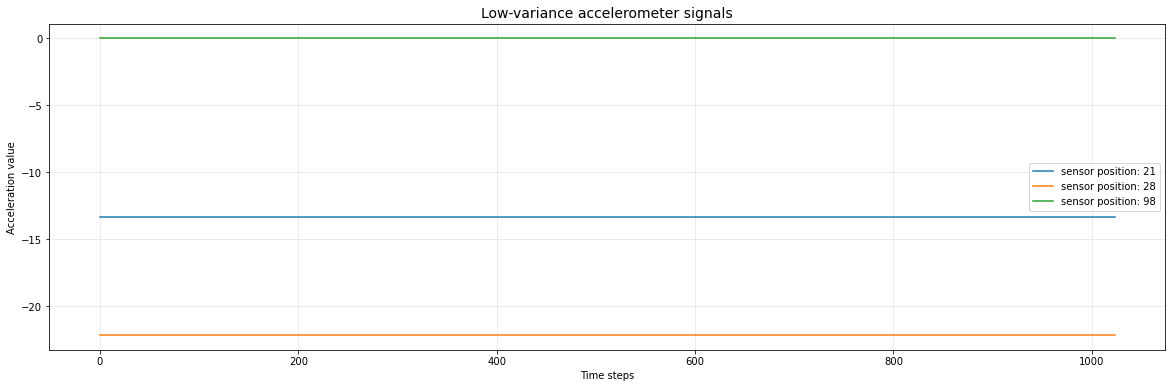

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))

for sensor_position in cste_sensors:
    plt.plot(dfvalid.iloc[sensor_position, :1024], label=f"sensor position: {sensor_position}")

plt.legend(loc="best")
plt.title("Low-variance accelerometer signals", fontsize=14)
plt.xlabel("Time steps")
plt.ylabel("Acceleration value")
plt.grid(alpha=0.3)
plt.show()

We remove these 3 sensors from the dataset : 

In [11]:
# Remove low-variance sensors from validation data and ground truth.

low_variance_index = dfvalid.index[cste_sensors]
print(f"Low-variance sensors removed: {len(low_variance_index)}")

dfvalid = dfvalid.drop(index=low_variance_index)
groundtruth = groundtruth.drop(index=low_variance_index)

print("dfvalid shape after low-variance removal:", dfvalid.shape)
print("groundtruth shape after low-variance removal:", groundtruth.shape)


Low-variance sensors removed: 3
dfvalid shape after low-variance removal: (566, 61440)
groundtruth shape after low-variance removal: (566, 2)


## Data Visualization

### Time series representations 

- Let's represent some sensors from dftrain dataset and dfvalid dataset :

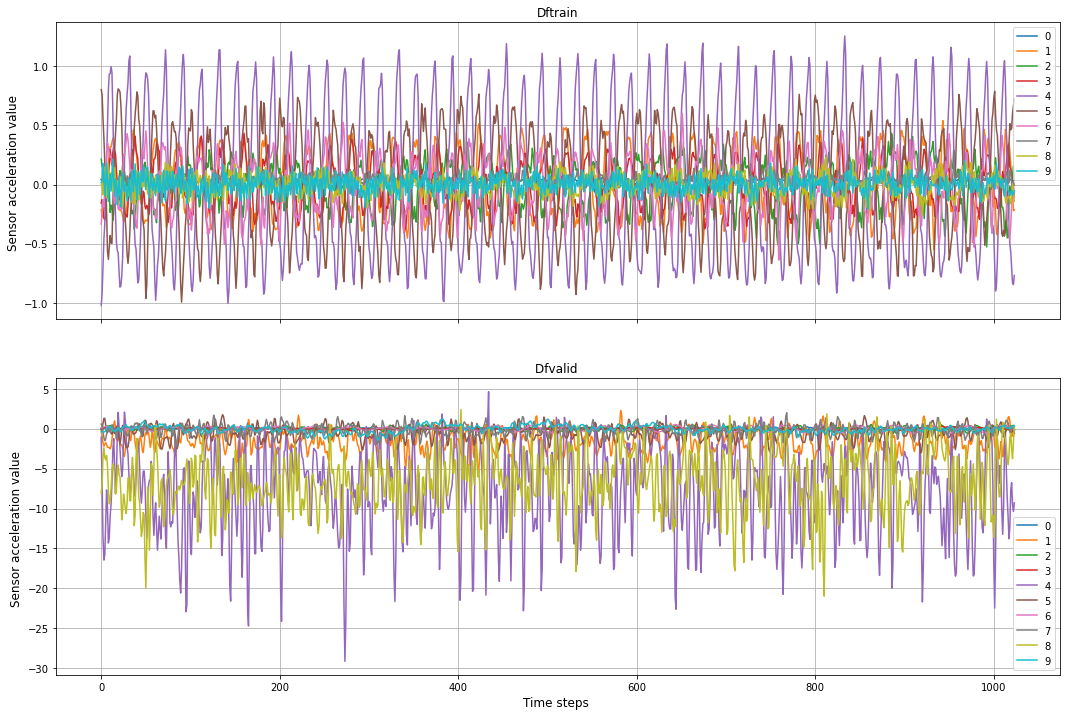

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

for i in range(0, 10):
    dftrain.iloc[i][:1024].plot(ax=ax1)
    dfvalid.iloc[i][:1024].plot(ax=ax2)
    ax1.grid()
    ax2.grid()
    ax1.set_xlabel("Time steps ", fontsize=12)
    ax2.set_xlabel("Time steps ", fontsize=12)
    ax1.set_ylabel("Sensor acceleration value ", fontsize=12)
    ax2.set_ylabel("Sensor acceleration value ", fontsize=12)
    ax1.set_title("Dftrain", fontsize=12)
    ax2.set_title("Dfvalid ", fontsize=12)
    ax1.legend()
    ax2.legend()
plt.savefig("Time series representation.jpg", dpi=300,
            orientation='landscape', bbox_inches="tight", pad_inches=0.5)

### Signals distribution

- Let's check the distribution :

Text(0.5, 1.0, 'Subset of distribution sensors measurements')

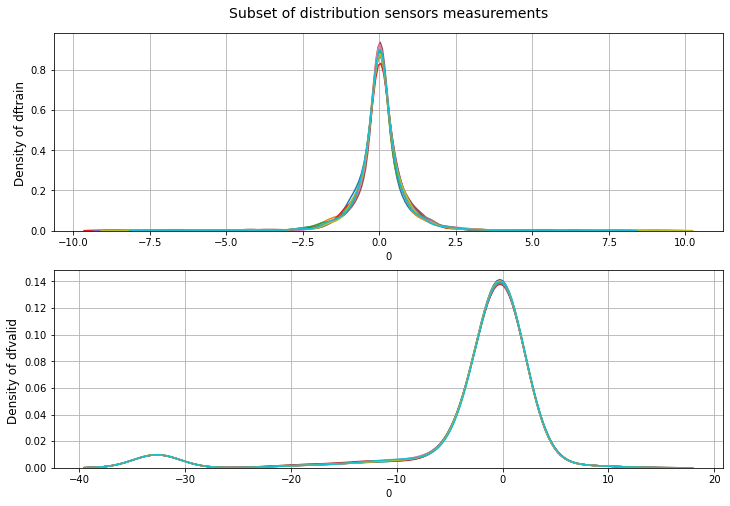

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
ax1.grid()
ax2.grid()

for i in range(0, 10):
    sns.kdeplot(dftrain[i], ax=ax1)
    sns.kdeplot(dfvalid[i], ax=ax2)
ax1.set_ylabel("Density of dftrain ", fontsize=12)
ax2.set_ylabel("Density of dfvalid ", fontsize=12)
ax1.set_title("Subset of distribution sensors measurements",
              fontsize=14, pad=15)

# Feature Extraction

I extract the features I need in Time domain. 

I extract the mean, the variance, the min, the max, the Skewness, the Kurtosis, the RMS, the CF, IF, SF and CLF :

In [14]:
# Feature extraction function for time-domain signals

def featuring(data):
    """
    Compute time-domain statistical features for each time series.

    Parameters
    ----------
    data : pandas.DataFrame
        Rows are sensors/sequences and columns are time steps.

    Returns
    -------
    pandas.DataFrame
        Feature matrix with one row per sequence.
    """
    eps = np.finfo(float).eps
    n_steps = data.shape[1]

    max_abs = data.abs().max(axis=1)
    mean_abs = data.abs().mean(axis=1)
    rms = np.sqrt((data ** 2).mean(axis=1))
    sqrt_abs_mean = np.sqrt(data.abs()).mean(axis=1)

    df_features = pd.DataFrame(index=data.index)
    df_features["Min"] = data.min(axis=1)
    df_features["Max"] = data.max(axis=1)
    df_features["Mean"] = data.mean(axis=1)
    df_features["Var"] = data.var(axis=1)
    df_features["RMS"] = rms
    df_features["Kurtosis"] = data.kurtosis(axis=1)
    df_features["Skewness"] = data.skew(axis=1)
    df_features["CF"] = max_abs / (rms + eps)
    df_features["IF"] = max_abs / (mean_abs + eps)
    df_features["SF"] = rms / (mean_abs + eps)
    df_features["CLF"] = max_abs / ((sqrt_abs_mean ** 2) + eps)

    return df_features

## Dftrain features

Let's compute the features for the training dataset : 

In [15]:
feat_dftrain = featuring(dftrain)
feat_dftrain

,Min,Max,Mean,Var,RMS,Kurtosis,Skewness,CF,IF,SF,CLF
0,-0.247552,0.299668,0.039373,0.000621,0.046595,13.577740,-0.040012,6.431291,7.124762,1.107828,7.492888
1,-1.295304,1.423423,0.003725,0.483785,0.695551,-1.407165,0.054606,2.046468,2.290557,1.119273,2.515785
2,-1.745115,1.748343,0.012775,0.726437,0.852402,-1.314121,0.002215,2.051079,2.332861,1.137383,2.598190
3,-0.748198,0.717880,0.004919,0.021038,0.145128,0.574434,-0.010889,5.155418,6.547920,1.270105,7.761487
4,-1.213873,1.402794,0.032258,0.430360,0.656805,-1.416846,0.118328,2.135783,2.384432,1.116420,2.606348
...,...,...,...,...,...,...,...,...,...,...,...
1672,-1.399150,1.364695,-0.005592,0.055536,0.235725,4.874854,0.035782,5.935518,8.562554,1.442596,10.640717
1673,-4.530277,3.961274,-0.039314,0.150969,0.390528,2.054798,-0.124365,11.600383,15.029130,1.295572,18.033436
1674,-2.757658,2.552845,-0.031425,0.235088,0.485872,0.978321,0.030666,5.675692,7.092513,1.249630,8.221422
1675,-1.603581,1.645138,-0.019918,0.172258,0.415514,-0.275255,0.119468,3.959287,4.883343,1.233389,5.712289


## Dfvalid features

Let's compute the features for the validation dataset :

In [16]:
feat_dfvalid = featuring(dfvalid)
feat_dfvalid

,Min,Max,Mean,Var,RMS,Kurtosis,Skewness,CF,IF,SF,CLF
sensors,,,,,,,,,,,
0,-0.382998,0.355729,0.007689,0.007263,0.085569,0.038758,-0.052750,4.475908,5.615078,1.254511,6.635838
1,-16.348537,4.276275,-1.922069,2.833101,2.554878,1.619499,-0.614441,6.398950,7.864098,1.228967,9.112766
2,-0.663285,0.654703,-0.008438,0.041078,0.202851,-1.008170,0.007239,3.269820,3.792019,1.159703,4.254506
3,-0.295476,0.469974,0.000922,0.003767,0.061380,0.649683,0.176908,7.656809,9.745002,1.272724,11.578752
4,-31.633011,7.472916,-7.428013,22.316734,8.802939,0.285508,-0.673614,3.593460,4.238905,1.179617,4.755847
...,...,...,...,...,...,...,...,...,...,...,...
588,-0.315141,0.236232,0.001953,0.005623,0.075009,-0.315640,-0.368181,4.201397,5.145221,1.224645,5.986628
589,-19.527720,-18.198016,-19.002274,0.107866,19.005112,-0.602937,0.476708,1.027498,1.027652,1.000149,1.027729
591,-2.068262,2.161117,0.038360,0.050360,0.227664,1.353855,0.134301,9.492583,12.150593,1.280009,14.435981


These 2 datasets will be used to train and test my model.

# Machine Learning: Anomaly Detection with LOF

## Preprocessing 

### Features selection based on correlation 

#### Features selection for dftrain

- I plot the correlation matrix for the dftrain_transform dataset :

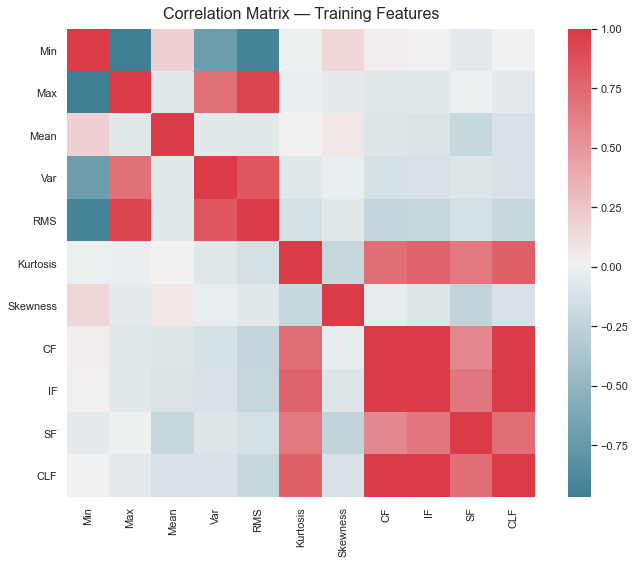

In [17]:
sns.set(style="white")
fig, ax = plt.subplots(figsize=(10, 8))

corr = feat_dftrain.corr()
mask = np.zeros_like(corr, dtype=bool)

sns.heatmap(
    corr,
    mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    square=True,
    ax=ax
)

ax.set_title("Correlation Matrix — Training Features", fontsize=16, pad=10)
plt.tight_layout()
plt.savefig("correlation_matrix_train.jpg", dpi=300, bbox_inches="tight", pad_inches=0.5)
plt.show()

- I compare the correlation between features and remove one of two features that have a correlation higher than 0.95 : 

In [18]:
# Select features using the training set only, then apply the same selection to validation data.
# This avoids data leakage and keeps both datasets aligned.

correlation_threshold = 0.95
upper_corr = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))

selected_columns = [
    column for column in upper_corr.columns
    if not any(upper_corr[column] > correlation_threshold)
]

dftrain_featured = feat_dftrain[selected_columns].copy()
dfvalid_featured = feat_dfvalid[selected_columns].copy()

print(f"Selected features ({len(selected_columns)}): {selected_columns}")
dftrain_featured.head()

Selected features (8): ['Min', 'Mean', 'Var', 'RMS', 'Kurtosis', 'Skewness', 'CF', 'SF']


,Min,Mean,Var,RMS,Kurtosis,Skewness,CF,SF
0,-0.247552,0.039373,0.000621,0.046595,13.577740,-0.040012,6.431291,1.107828
1,-1.295304,0.003725,0.483785,0.695551,-1.407165,0.054606,2.046468,1.119273
2,-1.745115,0.012775,0.726437,0.852402,-1.314121,0.002215,2.051079,1.137383
3,-0.748198,0.004919,0.021038,0.145128,0.574434,-0.010889,5.155418,1.270105
4,-1.213873,0.032258,0.430360,0.656805,-1.416846,0.118328,2.135783,1.116420


In [19]:
dftrain_featured.head()

,Min,Mean,Var,RMS,Kurtosis,Skewness,CF,SF
0,-0.247552,0.039373,0.000621,0.046595,13.577740,-0.040012,6.431291,1.107828
1,-1.295304,0.003725,0.483785,0.695551,-1.407165,0.054606,2.046468,1.119273
2,-1.745115,0.012775,0.726437,0.852402,-1.314121,0.002215,2.051079,1.137383
3,-0.748198,0.004919,0.021038,0.145128,0.574434,-0.010889,5.155418,1.270105
4,-1.213873,0.032258,0.430360,0.656805,-1.416846,0.118328,2.135783,1.116420


#### Validation features

The validation set uses exactly the same selected features as the training set.

- Correlation matrix on the validation set after applying the training-based feature selection:

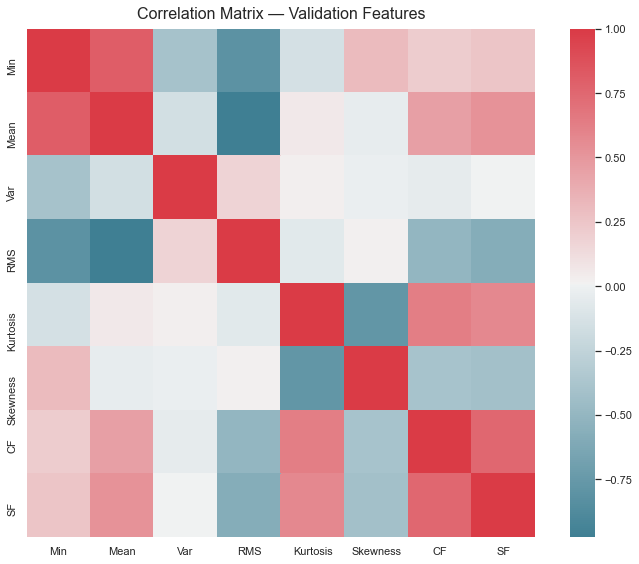

In [20]:
sns.set(style="white")
fig, ax = plt.subplots(figsize=(10, 8))

corr_valid = dfvalid_featured.corr()
mask = np.zeros_like(corr_valid, dtype=bool)

sns.heatmap(
    corr_valid,
    mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    square=True,
    ax=ax
)

ax.set_title("Correlation Matrix — Validation Features", fontsize=16, pad=10)
plt.tight_layout()
plt.show()

#### Feature scaling

LOF is distance-based, so features must be standardized. The scaler is fitted on the training set and then applied to the validation set.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

dftrain_transform = pd.DataFrame(
    scaler.fit_transform(dftrain_featured),
    index=dftrain_featured.index,
    columns=dftrain_featured.columns
)

dfvalid_transform = pd.DataFrame(
    scaler.transform(dfvalid_featured),
    index=dfvalid_featured.index,
    columns=dfvalid_featured.columns
)

dfvalid_transform.head()

,Min,Mean,Var,RMS,Kurtosis,Skewness,CF,SF
sensors,,,,,,,,
0,0.874719,-0.018637,-0.281138,-0.858129,-0.043415,-0.203444,0.109313,0.191881
1,-5.954977,-15.659392,0.684912,2.920214,1.054307,-2.459024,1.530931,-0.264250
2,0.754819,-0.149348,-0.269578,-0.678673,-0.770438,0.037454,-0.782293,-1.501053
3,0.912159,-0.073481,-0.282334,-0.895141,0.380833,0.718794,2.460809,0.517082
4,-12.493329,-60.285267,7.345655,12.480507,0.127937,-2.696643,-0.543040,-1.145462


## Anomaly Detection Algorithm Modeling

### Feature bagging

- I use 15% of the validation set to select hyperparameters. The remaining validation data is kept for final evaluation.

In [22]:
# Use the first 15% of the validation set for hyperparameter selection.
# Ground truth has already been cleaned and aligned with dfvalid.

groundtruth_beta = groundtruth.iloc[:85].copy()
groundtruth_beta.head()


,seqID,anomaly
sensors,,
0,0,0.0
1,1,1.0
2,2,0.0
3,3,0.0
4,4,1.0


In [23]:
# Validation subset used for hyperparameter selection

dfvalid_beta = dfvalid_transform.iloc[:85].copy()
dfvalid_beta.head()

,Min,Mean,Var,RMS,Kurtosis,Skewness,CF,SF
sensors,,,,,,,,
0,0.874719,-0.018637,-0.281138,-0.858129,-0.043415,-0.203444,0.109313,0.191881
1,-5.954977,-15.659392,0.684912,2.920214,1.054307,-2.459024,1.530931,-0.264250
2,0.754819,-0.149348,-0.269578,-0.678673,-0.770438,0.037454,-0.782293,-1.501053
3,0.912159,-0.073481,-0.282334,-0.895141,0.380833,0.718794,2.460809,0.517082
4,-12.493329,-60.285267,7.345655,12.480507,0.127937,-2.696643,-0.543040,-1.145462


To find the best hyperparameters of my model, I use a featurebagging method : 

In [24]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from pyod.models.lof import LOF
from pyod.models.feature_bagging import FeatureBagging

neighbors_grid = [3, 5, 10, 50, 100, 125, 150]
estimators_grid = list(range(10, 300, 20))

Scores = pd.DataFrame(index=neighbors_grid, columns=estimators_grid, dtype=float)

for n_neighbors in tqdm(neighbors_grid):
    for n_estimators in estimators_grid:
        model = FeatureBagging(
            LOF(n_neighbors=n_neighbors),
            n_estimators=n_estimators
        )
        model.fit(dftrain_transform)

        # PyOD decision_function returns anomaly scores: higher = more abnormal.
        train_scores_grid = model.decision_function(dftrain_transform)
        threshold_grid = train_scores_grid.max()

        validation_scores_grid = model.decision_function(dfvalid_beta)
        y_pred_beta = (validation_scores_grid > threshold_grid).astype(int)

        Scores.loc[n_neighbors, n_estimators] = accuracy_score(
            groundtruth_beta["anomaly"].astype(int),
            y_pred_beta
        )

Scores


100%|██████████| 7/7 [14:55<00:00, 127.86s/it]


,10,30,50,70,90,110,130,150,170,190,210,230,250,270,290
3,0.847059,0.870588,0.847059,0.870588,0.858824,0.847059,0.847059,0.870588,0.847059,0.858824,0.858824,0.847059,0.858824,0.870588,0.858824
5,0.835294,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059
10,0.811765,0.811765,0.800000,0.800000,0.800000,0.811765,0.800000,0.800000,0.800000,0.800000,0.800000,0.800000,0.800000,0.811765,0.800000
50,0.752941,0.752941,0.729412,0.729412,0.717647,0.717647,0.717647,0.729412,0.717647,0.717647,0.717647,0.717647,0.717647,0.717647,0.717647
100,0.717647,0.729412,0.729412,0.729412,0.776471,0.741176,0.800000,0.752941,0.788235,0.752941,0.764706,0.741176,0.741176,0.741176,0.729412
125,0.811765,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.752941,0.729412,0.729412,0.729412,0.729412,0.729412
150,0.764706,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412


In [25]:
Scores

,10,30,50,70,90,110,130,150,170,190,210,230,250,270,290
3,0.847059,0.870588,0.847059,0.870588,0.858824,0.847059,0.847059,0.870588,0.847059,0.858824,0.858824,0.847059,0.858824,0.870588,0.858824
5,0.835294,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059,0.847059
10,0.811765,0.811765,0.800000,0.800000,0.800000,0.811765,0.800000,0.800000,0.800000,0.800000,0.800000,0.800000,0.800000,0.811765,0.800000
50,0.752941,0.752941,0.729412,0.729412,0.717647,0.717647,0.717647,0.729412,0.717647,0.717647,0.717647,0.717647,0.717647,0.717647,0.717647
100,0.717647,0.729412,0.729412,0.729412,0.776471,0.741176,0.800000,0.752941,0.788235,0.752941,0.764706,0.741176,0.741176,0.741176,0.729412
125,0.811765,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.752941,0.729412,0.729412,0.729412,0.729412,0.729412
150,0.764706,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412,0.729412


The grid search results are stored in `Scores`, where rows represent `n_neighbors` and columns represent `n_estimators`.

The best configuration is selected based on validation accuracy while keeping the model simple and stable.

In [26]:
best_score = Scores.max().max()
best_n_neighbors, best_n_estimators = Scores.stack().idxmax()

print(f"Best accuracy: {best_score:.3f}")
print(f"Best n_neighbors: {best_n_neighbors}")
print(f"Best n_estimators: {best_n_estimators}")

Best accuracy: 0.871
Best n_neighbors: 3
Best n_estimators: 30


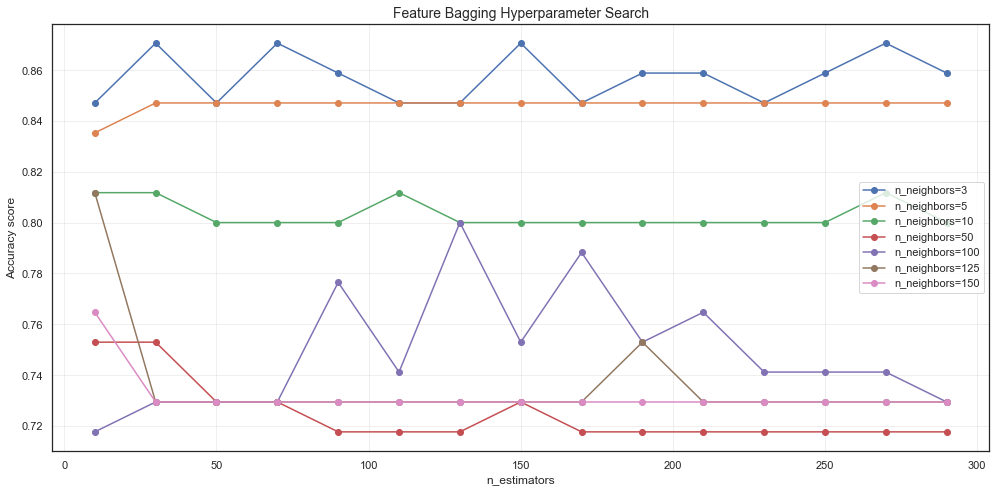

In [27]:
plt.figure(figsize=(14, 7))

for n_neighbors in Scores.index:
    plt.plot(Scores.columns, Scores.loc[n_neighbors], marker="o", label=f"n_neighbors={n_neighbors}")

plt.xlabel("n_estimators")
plt.ylabel("Accuracy score")
plt.title("Feature Bagging Hyperparameter Search", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Based on the hyperparameter search, I train the final LOF feature-bagging model. In the original analysis, the selected configuration was `n_neighbors = 3` and `n_estimators = 30`, which provides strong performance and stability.

In [28]:
from pyod.models.feature_bagging import FeatureBagging
from pyod.models.lof import LOF

best_n_neighbors = 3
best_n_estimators = 30

mod_lof = FeatureBagging(
    LOF(n_neighbors=best_n_neighbors),
    n_estimators=best_n_estimators
)

mod_lof.fit(dftrain_transform)

FeatureBagging(base_estimator=LOF(algorithm='auto', contamination=0.1, leaf_size=30, metric='minkowski',
  metric_params=None, n_jobs=1, n_neighbors=3, novelty=True, p=2),
        bootstrap_features=False, check_detector=True,
        check_estimator=False, combination='average', contamination=0.1,
        estimator_params={}, max_features=1.0, n_estimators=30, n_jobs=1,
        random_state=None, verbose=0)

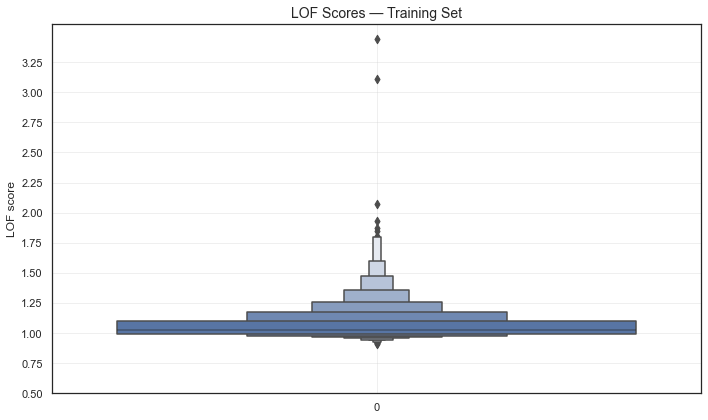

In [29]:
train_scores = mod_lof.decision_function(dftrain_transform)

plt.figure(figsize=(10, 6))
sns.boxenplot(data=train_scores)
plt.yticks(np.arange(0.5, 3.5, 0.25))
plt.grid(axis="both", alpha=0.3)
plt.ylabel("LOF score")
plt.title("LOF Scores — Training Set", fontsize=14)
plt.tight_layout()
plt.savefig("lof_scores_train.jpg", dpi=300, bbox_inches="tight", pad_inches=0.5)
plt.show()

In [30]:
train_scores

array([2.06855372, 1.07926473, 0.99973092, ..., 1.13024076, 1.00863981,
       3.44254969])

# BOOTSTRAP 

3 datasets : 
   - dftrain(jeu de données signaux normaux)
   - dfvalid (jeu de données test avec signaux normaux et anormaux)
   - groundtruth ( jeu de données donnant le statut de chaque capteurs du dataset dfvalid)

******************************************

- Bootstrap

In [31]:
# Keep the remaining validation data for final evaluation.
# Because dfvalid and groundtruth have been cleaned together, iloc keeps both aligned.

dfvalid_transform2 = dfvalid_transform.iloc[85:].copy()
groundtruth2 = groundtruth.iloc[85:].copy()

print("Final validation features:", dfvalid_transform2.shape)
print("Final ground truth:", groundtruth2.shape)
print(groundtruth2["anomaly"].value_counts())


Final validation features: (481, 8)
Final ground truth: (481, 2)
0.0    252
1.0    229
Name: anomaly, dtype: int64


The model is trained only on normal training sequences. The remaining validation set is used for final evaluation against the ground truth labels.

In [32]:
# The threshold is defined as the maximum LOF score observed on normal training data.

threshold = train_scores.max()
print(f"LOF threshold: {threshold:.3f}")

LOF threshold: 3.443


Sequences with a LOF score above the training threshold are classified as anomalous.

In [33]:
# Compute LOF anomaly scores on the final validation set and classify anomalies.
# In PyOD, higher decision_function scores indicate more abnormal observations.

validation_scores = mod_lof.decision_function(dfvalid_transform2)
prediction = (validation_scores > threshold).astype(int)

print("Predicted class distribution:")
print(pd.Series(prediction, name="prediction").value_counts())
prediction[:10]


Predicted class distribution:
0    321
1    160
Name: prediction, dtype: int64


array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0])

In [34]:
# Ground truth labels: 0 = normal, 1 = anomaly

y_true = groundtruth2["anomaly"].astype(int).values
pd.Series(y_true, name="anomaly").value_counts()


0    252
1    229
Name: anomaly, dtype: int64

Confusion matrix:
[[252   0]
 [ 69 160]]
Metrics:


accuracy               0.856549
precision              1.000000
recall                 0.698690
f1_score               0.822622
false_positive_rate    0.000000
dtype: float64

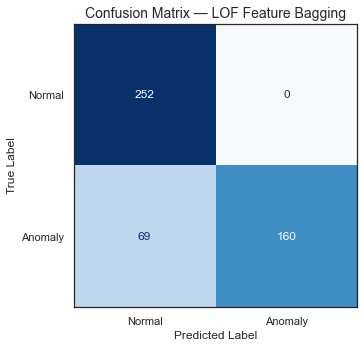

In [36]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

conf_matrix = confusion_matrix(y_true, prediction)
tn, fp, fn, tp = conf_matrix.ravel()

metrics = pd.Series({
    "accuracy": accuracy_score(y_true, prediction),
    "precision": precision_score(y_true, prediction, zero_division=0),
    "recall": recall_score(y_true, prediction, zero_division=0),
    "f1_score": f1_score(y_true, prediction, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
})

print("Confusion matrix:")
print(conf_matrix)
print("Metrics:")
display(metrics)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["Normal", "Anomaly"]
).plot(cmap="Blues", colorbar=False, ax=ax)

ax.set_title("Confusion Matrix — LOF Feature Bagging", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.grid(False)
plt.tight_layout()
plt.savefig("confusion_matrix_lof.jpg", dpi=300, bbox_inches="tight", pad_inches=0.5)
plt.show()


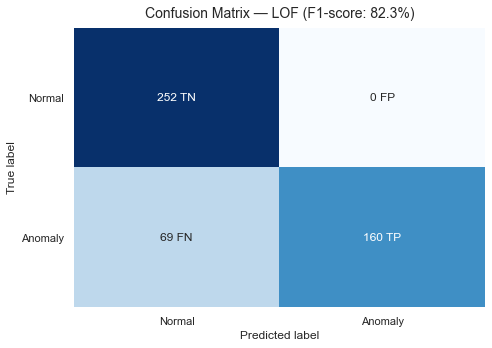

In [37]:
annot = np.array([
    [f"{tn} TN", f"{fp} FP"],
    [f"{fn} FN", f"{tp} TP"]
])

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=annot,
    annot_kws={"size": 12},
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.xticks(np.arange(0, 2) + 0.5, labels=["Normal", "Anomaly"])
plt.yticks(np.arange(0, 2) + 0.5, labels=["Normal", "Anomaly"], rotation=0)
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("True label", fontsize=12)
plt.title(f"Confusion Matrix — LOF (F1-score: {metrics['f1_score']:.1%})", fontsize=14, pad=10)
plt.tight_layout()
plt.savefig("confusion_matrix_lof.jpg", dpi=300, bbox_inches="tight", pad_inches=0.5)
plt.show()

No Skill: ROC AUC = 0.500
LOF: ROC AUC = 0.974


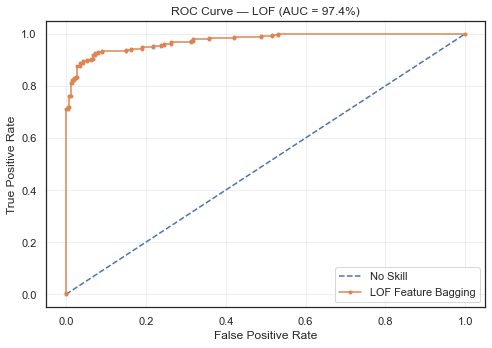

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Baseline model: constant no-skill scores.
ns_scores = np.zeros(len(y_true))

ns_auc = roc_auc_score(y_true, ns_scores)
lof_auc = roc_auc_score(y_true, validation_scores)

print(f"No Skill: ROC AUC = {ns_auc:.3f}")
print(f"LOF: ROC AUC = {lof_auc:.3f}")

ns_fpr, ns_tpr, _ = roc_curve(y_true, ns_scores)
lof_fpr, lof_tpr, _ = roc_curve(y_true, validation_scores)

plt.figure(figsize=(7, 5))
plt.plot(ns_fpr, ns_tpr, linestyle="--", label="No Skill")
plt.plot(lof_fpr, lof_tpr, marker=".", label="LOF Feature Bagging")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — LOF (AUC = {lof_auc:.1%})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_lof.jpg", dpi=300, bbox_inches="tight", pad_inches=0.5)
plt.show()


In [39]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    prediction,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


              precision    recall  f1-score   support

      Normal       0.79      1.00      0.88       252
     Anomaly       1.00      0.70      0.82       229

    accuracy                           0.86       481
   macro avg       0.89      0.85      0.85       481
weighted avg       0.89      0.86      0.85       481



## Final Evaluation & Discussion

The final model achieves strong performance with an accuracy of 86% and an F1-score of approximately 0.85.

A key result is the **zero false positive rate**, meaning that no normal signals are incorrectly classified as anomalies. This is particularly important in an industrial context, where false alarms would lead to unnecessary inspections and increased operational costs.

However, the model detects approximately 70% of anomalies, meaning that some abnormal signals remain undetected. This reflects a **conservative detection strategy**, prioritizing reliability over sensitivity.

This trade-off is intentional and aligned with the project objective: ensuring high confidence in detected anomalies while minimizing false alerts.

Overall, the model provides a robust and practical solution for automated anomaly detection in helicopter sensor data.


## Evaluation Notes

ROC curves are useful when classes are reasonably balanced. Precision-recall metrics are often more informative when the positive class is rare.

In this industrial anomaly detection use case, the false positive rate is especially important because too many false alarms would increase manual inspection workload.

## Conclusion

This project implements an unsupervised anomaly detection pipeline for helicopter accelerometer time series.

Key outcomes:

- Time-domain features provide useful information for detecting abnormal vibration patterns.
- LOF is suitable because the training data contains only normal sequences.
- Feature Bagging improves robustness by combining multiple LOF estimators.
- The final model achieves strong performance while keeping the false positive rate low.

This makes the approach relevant for automated sensor validation in flight-test contexts.